# GemmaX / MiLMMT — Multilingual Machine Translation Demo (Google Colab)

This notebook demonstrates [xiaomi-research/gemmax](https://github.com/xiaomi-research/gemmax): open translation LLMs built on Google's Gemma models.

| Family | Languages | Sizes | Base |
|---|---|---|---|
| **GemmaX2-28** | 28 | 2B, 9B | Gemma 2 |
| **MiLMMT-46** (latest, v1.0) | 46 | 1B, 4B, 12B | Gemma 3 |

**What's covered**

1. Setup & GPU check
2. Load a MiLMMT / GemmaX2 checkpoint (auto-picks dtype / 4-bit for your GPU)
3. The official translation prompt format
4. Single, batch and one-to-many translation (incl. Khmer, Thai, Lao, Vietnamese…)
5. Reference-free round-trip check with chrF
6. An interactive translator widget
7. *(Optional)* fast inference with vLLM
8. *(Optional)* the repo's training data formats and the SFT↔RL **linear model merge** script

> **Runtime:** `Runtime → Change runtime type → GPU`. A free **T4** runs the 1B model comfortably and the 4B model in 4-bit. The 12B model needs an **A100/L4** (or 4-bit on L4).

## 1. Check the GPU

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), "| bf16 supported:", torch.cuda.is_bf16_supported())

name, memory.total [MiB]
Tesla T4, 15360 MiB
CUDA available: True
GPU: Tesla T4 | bf16 supported: True


## 2. Install dependencies

In [2]:
!pip install -q -U "transformers>=4.50" accelerate bitsandbytes sacrebleu ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.9 MB/s eta 0:00:00


## 3. Choose and load a model

The default `MiLMMT-46-1B-v1.0` downloads fast (~2 GB) and fits any Colab GPU.
Switch to `4B` or `12B` for better quality.

> ⚠️ The `*-Pretrain` checkpoints are **not** translation models — use the `v0.1`/`v0.2`/`v1.0` ones.

**Precision logic:** Gemma 3 is unstable in fp16, so on GPUs without bf16 (e.g. T4) we use fp32 for small models and 4-bit (fp32 compute) for larger ones.

In [3]:
#@title Model selection { run: "auto" }
MODEL_ID = "xiaomi-research/MiLMMT-46-1B-v1.0"  #@param ["xiaomi-research/MiLMMT-46-1B-v1.0", "xiaomi-research/MiLMMT-46-4B-v1.0", "xiaomi-research/MiLMMT-46-12B-v1.0", "xiaomi-research/MiLMMT-46-1B-v0.1", "xiaomi-research/GemmaX2-28-2B-v0.2", "xiaomi-research/GemmaX2-28-9B-v0.2"]
FORCE_4BIT = False  #@param {type:"boolean"}
print(MODEL_ID)

xiaomi-research/MiLMMT-46-1B-v1.0


In [4]:
import torch, time, gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bf16_ok = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
gpu_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0

# Rough parameter count from the model name, used to pick a loading strategy
size_b = next(float(t[:-1]) for t in MODEL_ID.split("-") if t.endswith("B") and t[:-1].replace(".", "").isdigit())

load_kwargs = dict(device_map="auto")
if FORCE_4BIT or (bf16_ok and size_b * 2.2 > gpu_gb) or (not bf16_ok and size_b * 4.4 > gpu_gb):
    load_kwargs["quantization_config"] = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16 if bf16_ok else torch.float32,
    )
    mode = "4-bit NF4"
else:
    load_kwargs["torch_dtype"] = torch.bfloat16 if bf16_ok else torch.float32
    mode = str(load_kwargs["torch_dtype"])

print(f"Loading {MODEL_ID} ({size_b}B) as {mode} on a {gpu_gb:.0f} GB GPU ...")
t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "left"          # required for batched generation with decoder-only models
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **load_kwargs)
model.eval()
print(f"Loaded in {time.time()-t0:.0f}s | GPU memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Loading xiaomi-research/MiLMMT-46-1B-v1.0 (1.0B) as torch.bfloat16 on a 16 GB GPU ...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/1.63k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

...

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

Loaded in 43s | GPU memory used: 2.0 GB


## 4. The translation prompt

The models were trained with this exact template (use the language names exactly as listed):

```text
Translate this from <source language name> to <target language name>:
<source language name>: <source language sentence>
<target language name>:
```

In [5]:
MILMMT_46 = [
    "Arabic", "Azerbaijani", "Bulgarian", "Bengali", "Catalan", "Czech", "Danish", "German", "Greek",
    "English", "Spanish", "Persian", "Finnish", "French", "Hebrew", "Hindi", "Croatian", "Hungarian",
    "Indonesian", "Italian", "Japanese", "Kazakh", "Khmer", "Korean", "Lao", "Malay", "Burmese",
    "Norwegian", "Dutch", "Polish", "Portuguese", "Romanian", "Russian", "Slovak", "Slovenian", "Swedish",
    "Tamil", "Thai", "Tagalog", "Turkish", "Urdu", "Uzbek", "Vietnamese", "Cantonese",
    "Chinese (Simplified)", "Chinese (Traditional)",
]
GEMMAX2_28 = [
    "Arabic", "Bengali", "Czech", "German", "English", "Spanish", "Persian", "French", "Hebrew", "Hindi",
    "Indonesian", "Italian", "Japanese", "Khmer", "Korean", "Lao", "Malay", "Burmese", "Dutch", "Polish",
    "Portuguese", "Russian", "Thai", "Tagalog", "Turkish", "Urdu", "Vietnamese", "Chinese",
]
LANGUAGES = GEMMAX2_28 if "GemmaX2" in MODEL_ID else MILMMT_46
ZH = "Chinese" if "GemmaX2" in MODEL_ID else "Chinese (Simplified)"
print(f"{len(LANGUAGES)} supported languages:", ", ".join(LANGUAGES))

def build_prompt(text: str, src: str, tgt: str) -> str:
    assert src in LANGUAGES and tgt in LANGUAGES, f"Unsupported language: {src} / {tgt}"
    return f"Translate this from {src} to {tgt}:\n{src}: {text}\n{tgt}:"

print("\n--- Example prompt ---")
print(build_prompt("我爱机器翻译", ZH, "English"))

46 supported languages: Arabic, Azerbaijani, Bulgarian, Bengali, Catalan, Czech, Danish, German, Greek, English, Spanish, Persian, Finnish, French, Hebrew, Hindi, Croatian, Hungarian, Indonesian, Italian, Japanese, Kazakh, Khmer, Korean, Lao, Malay, Burmese, Norwegian, Dutch, Polish, Portuguese, Romanian, Russian, Slovak, Slovenian, Swedish, Tamil, Thai, Tagalog, Turkish, Urdu, Uzbek, Vietnamese, Cantonese, Chinese (Simplified), Chinese (Traditional)

--- Example prompt ---
Translate this from Chinese (Simplified) to English:
Chinese (Simplified): 我爱机器翻译
English:


## 5. Translation helper (batched, greedy decoding)

In [6]:
@torch.inference_mode()
def translate(texts, src, tgt, max_new_tokens=512, batch_size=8):
    """Translate a string or list of strings from `src` to `tgt`."""
    single = isinstance(texts, str)
    texts = [texts] if single else list(texts)
    results = []
    for i in range(0, len(texts), batch_size):
        prompts = [build_prompt(t, src, tgt) for t in texts[i:i + batch_size]]
        # README uses add_special_tokens=False — the prompt is fed exactly as trained
        enc = tokenizer(prompts, add_special_tokens=False, return_tensors="pt", padding=True).to(model.device)
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,                  # greedy == top_k=1, temperature=0 in the README
            pad_token_id=tokenizer.pad_token_id,
        )
        new_tokens = out[:, enc["input_ids"].shape[1]:]   # keep only generated part
        results += [s.strip() for s in tokenizer.batch_decode(new_tokens, skip_special_tokens=True)]
    return results[0] if single else results

print(translate("我爱机器翻译", ZH, "English"))

I love machine translation


## 6. Demo: single sentences across language pairs

In [7]:
examples = [
    ("The weather in Phnom Penh is hot and humid today.", "English", "Khmer"),
    ("Machine translation helps people communicate across languages.", "English", "Japanese"),
    ("Nos traditions de nourriture sont maintenues vivantes par de petits fermiers.", "French", "English"),
    ("As a star ages, its spin rate begins to slow down.", "English", ZH),
    ("Ich möchte morgen früh einen Tisch für zwei Personen reservieren.", "German", "Spanish"),
]
for text, src, tgt in examples:
    t0 = time.time()
    out = translate(text, src, tgt)
    print(f"[{src} → {tgt}]  ({time.time()-t0:.1f}s)\n  {text}\n  {out}\n")

[English → Khmer]  (3.6s)
  The weather in Phnom Penh is hot and humid today.
  ស្ថានភាពអាកាសនៅភ្នំពេញនៅថ្ងៃនេះក្តៅ និងមានសំណើមខ្លាំង។

[English → Japanese]  (2.6s)
  Machine translation helps people communicate across languages.
  機械翻訳は人々が複数の言語でコミュニケーションを取るのを助けます。

[French → English]  (1.0s)
  Nos traditions de nourriture sont maintenues vivantes par de petits fermiers.
  Our food traditions are kept alive by small farmers.

[English → Chinese (Simplified)]  (1.2s)
  As a star ages, its spin rate begins to slow down.
  随着恒星的年龄增长，其自转速度开始减慢。

[German → Spanish]  (1.2s)
  Ich möchte morgen früh einen Tisch für zwei Personen reservieren.
  Quiero reservar una mesa para dos personas mañana por la mañana.



## 7. One-to-many: translate one sentence into many languages

Each target language needs its own prompt, so we loop over targets (each call is itself batched).

In [18]:
sentence = "Education is the most powerful weapon which you can use to change the world."
targets = [l for l in ["Khmer"] if l in LANGUAGES]

t0 = time.time()
rows = [(tgt, translate(sentence, "English", tgt)) for tgt in targets]
print(f"{len(rows)} translations in {time.time()-t0:.1f}s\n")
for tgt, out in rows:
    print(f"{tgt:>22}: {out}")

1 translations in 1.8s

                 Khmer: ការអប់រំគឺជាអាវុធដ៏មានឥទ្ធិពលបំផុត ដែលអ្នកអាចប្រើប្រាស់ដើម្បីផ្លាស់ប្តូរពិភពលោក។


## 8. Batch translation of a document

The model translates sentence-by-sentence; split longer text and translate the pieces in a batch.

In [9]:
import re
doc = """Angkor Wat is a temple complex in Cambodia. It was originally constructed in the 12th century.
It is considered the largest religious structure in the world. Every year, millions of tourists visit the site.
The temple is a symbol of Cambodia and appears on its national flag."""

sentences = [s for s in re.split(r"(?<=[.!?])\s+", doc.strip()) if s]
t0 = time.time()
khmer = translate(sentences, "English", "Khmer", batch_size=8)
print(f"Batch of {len(sentences)} sentences in {time.time()-t0:.1f}s\n")
for en, km in zip(sentences, khmer):
    print(f"EN: {en}\nKM: {km}\n")

Batch of 5 sentences in 2.6s

EN: Angkor Wat is a temple complex in Cambodia.
KM: អង្គរវត្ត គឺជាសំណង់ប្រាសាទមួយនៅប្រទេសកម្ពុជា។

EN: It was originally constructed in the 12th century.
KM: វាត្រូវបានសាងសង់ដំបូងនៅសតវត្សទី១២។

EN: It is considered the largest religious structure in the world.
KM: វាត្រូវបានចាត់ទុកថាជាហេដ្ឋារចនាសម្ព័ន្ធសាសនាធំជាងគេបំផុតនៅលើពិភពលោក។

EN: Every year, millions of tourists visit the site.
KM: ជារៀងរាល់ឆ្នាំ អ្នកទេសចររាប់លាននាក់បានមកទស្សនាទីនោះ។

EN: The temple is a symbol of Cambodia and appears on its national flag.
KM: ប្រាសាទនេះគឺជាសញ្ញានៃប្រទេសកម្ពុជា ហើយក៏បានបង្ហាញនៅលើទង់ជាតិរបស់ប្រទេសផងដែរ។



## 9. Reference-free quality check: round-trip translation + chrF

Without references we can translate **English → X → English** and score the back-translation against the original with chrF (sacrebleu).
This is only a rough sanity signal (errors can cancel out), but it's handy for comparing languages or model sizes.

In [19]:
import sacrebleu

test_sents = [
    "The children are playing football in the park.",
    "Please turn off the lights when you leave the room.",
    "The new hospital will open next month and create two hundred jobs.",
    "Rice is the most important crop in many Asian countries.",
    "She has been learning to play the piano for three years.",
]
pivots = [l for l in ["Khmer"] if l in LANGUAGES]

scores = {}
for lang in pivots:
    fwd = translate(test_sents, "English", lang)
    back = translate(fwd, lang, "English")
    scores[lang] = sacrebleu.corpus_chrf(back, [test_sents]).score
    print(f"{lang:>22}: round-trip chrF = {scores[lang]:.1f}   e.g. '{back[0]}'")

                 Khmer: round-trip chrF = 84.5   e.g. 'Children are playing football in the park.'


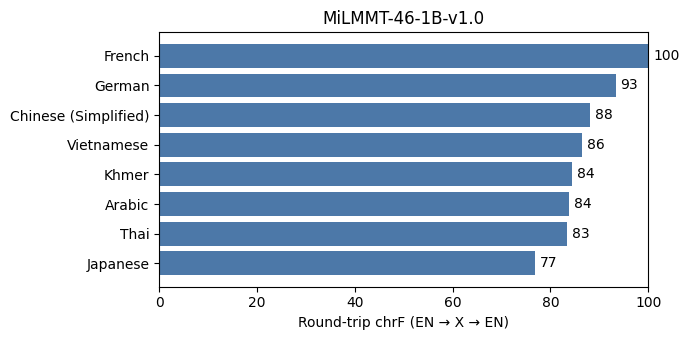

In [11]:
import matplotlib.pyplot as plt
langs, vals = zip(*sorted(scores.items(), key=lambda kv: kv[1]))
plt.figure(figsize=(7, 3.5))
plt.barh(langs, vals, color="#4C78A8")
plt.xlabel("Round-trip chrF (EN → X → EN)")
plt.title(MODEL_ID.split("/")[-1])
plt.xlim(0, 100)
for y, v in enumerate(vals):
    plt.text(v + 1, y, f"{v:.0f}", va="center")
plt.tight_layout(); plt.show()

## 10. Interactive translator

In [20]:
import ipywidgets as w
from IPython.display import display
try:
    from google.colab import output; output.enable_custom_widget_manager()
except Exception:
    pass

src_dd = w.Dropdown(options=LANGUAGES, value="English", description="From")
tgt_dd = w.Dropdown(options=["Khmer"], value="Khmer", description="To")
inp = w.Textarea(value="Good morning! How can I help you today?", layout=w.Layout(width="95%", height="90px"))
btn = w.Button(description="Translate", button_style="primary", icon="language")
swap = w.Button(description="⇄ Swap")
out = w.Textarea(layout=w.Layout(width="95%", height="90px"))
status = w.Label()

def on_translate(_):
    status.value = "Translating..."
    t0 = time.time()
    lines = [l for l in inp.value.split("\n") if l.strip()]
    out.value = "\n".join(translate(lines, src_dd.value, tgt_dd.value)) if lines else ""
    status.value = f"Done in {time.time()-t0:.1f}s"

def on_swap(_):
    src_dd.value, tgt_dd.value = tgt_dd.value, src_dd.value
    inp.value, out.value = out.value or inp.value, ""

btn.on_click(on_translate); swap.on_click(on_swap)
display(w.VBox([w.HBox([src_dd, swap, tgt_dd]), inp, w.HBox([btn, status]), out]))

## 11. *(Optional)* Fast inference with vLLM

vLLM gives much higher throughput for large batches. It is a heavy install and needs its own GPU memory,
so **restart the runtime** (`Runtime → Restart session`) before running this section to free the Transformers model.
On a T4 use the 1B model with `dtype="float32"`; on A100/L4 use `bfloat16`.

In [13]:
RUN_VLLM = False  #@param {type:"boolean"}
if RUN_VLLM:
    !pip install -q vllm

In [14]:
if RUN_VLLM:
    import torch
    from vllm import LLM, SamplingParams

    VLLM_MODEL = "xiaomi-research/MiLMMT-46-1B-v1.0"
    llm = LLM(model=VLLM_MODEL,
              dtype="bfloat16" if torch.cuda.is_bf16_supported() else "float32",
              max_model_len=2048, gpu_memory_utilization=0.85)
    params = SamplingParams(top_k=1, temperature=0, max_tokens=512)

    srcs = ["Good morning!", "Where is the train station?", "Thank you very much for your help."] * 10
    prompts = [f"Translate this from English to Khmer:\nEnglish: {s}\nKhmer:" for s in srcs]
    import time; t0 = time.time()
    outs = llm.generate(prompts, params)
    print(f"{len(prompts)} sentences in {time.time()-t0:.1f}s")
    for s, o in list(zip(srcs, outs))[:3]:
        print(s, "→", o.outputs[0].text.strip())

## 12. *(Optional)* Inside the repo: training data formats & model merging

The repo trains in three stages — **continual pretraining** and **SFT** with LlamaFactory, then **GRPO RL** with verl using
reference-free rewards (xCOMET / CometKiwi QE + an OpenLID language gate) — and finally **linearly merges** the SFT and RL weights:

$$\theta_{merged} = \alpha\,\theta_{SFT} + (1-\alpha)\,\theta_{RL}$$

Full training needs multi-GPU clusters, but we can inspect the data formats and run the merge script on the 1B models.

In [15]:
!git clone -q --depth 1 https://github.com/xiaomi-research/gemmax /content/gemmax 2>/dev/null || echo "already cloned"
import json
for name in ["cpt", "sft", "rl"]:
    data = json.load(open(f"/content/gemmax/examples/{name}.json"))
    print(f"===== examples/{name}.json  ({len(data)} samples) — first sample =====")
    print(json.dumps(data[0], ensure_ascii=False, indent=2)[:800], "\n")

===== examples/cpt.json  (13 samples) — first sample =====
{
  "text": "как проходит прощание с умершими\nЕсли прощание с покойным будет происходить в церкви либо синагоге, нужноОбычно тело умершего остается в похоронном бюро до дня похорон.Если похороны покойного прошли вдали от дома, родные и близкие могут позже заказать мемориальную панихиду. 9.Я определился, как пройдут похороны. Как все устроить? 10.Что еще нужно сделать перед прощанием? 11.Есть ли льготы?В Москве с 2012 года действует приказ, согласно которому в любом случае тело умершего должен осмотреть патологоанатом, и по умолчанию Даже завзятые материалисты хотят знать, что случается после смерти с близким родственником, как душа умершего прощается с родными и должны ли живые помогать ей. Во всех религиях есть поверья, привязанные к погребению, похороны могут проводиться по разным тради 

===== examples/sft.json  (3 samples) — first sample =====
{
  "instruction": "Translate this from French to English:",
  "input": "French:

**Merge demo.** The released `v1.0` = merge(SFT `v0.1`, RL checkpoint). The RL-only checkpoint isn't published, so as an
*illustration* of the script we interpolate `v0.1` with `v1.0` itself (α = 0.5) and compare outputs. This downloads ~4 GB and
frees the current model first.

In [16]:
RUN_MERGE_DEMO = False  #@param {type:"boolean"}
if RUN_MERGE_DEMO:
    from huggingface_hub import snapshot_download
    del model; gc.collect(); torch.cuda.empty_cache()
    a = snapshot_download("xiaomi-research/MiLMMT-46-1B-v0.1")
    b = snapshot_download("xiaomi-research/MiLMMT-46-1B-v1.0")
    !python /content/gemmax/scripts/linear_merge.py --model_a {a} --model_b {b} --alpha 0.5 --out /content/merged-1B --overwrite
    # copy tokenizer/config files so the merged dir is loadable
    !cp -n {b}/*.json {b}/*.model /content/merged-1B/ 2>/dev/null; ls -lh /content/merged-1B

In [17]:
if RUN_MERGE_DEMO:
    test = ["The committee postponed its decision until further evidence becomes available."]
    for ckpt in ["xiaomi-research/MiLMMT-46-1B-v0.1", "/content/merged-1B", "xiaomi-research/MiLMMT-46-1B-v1.0"]:
        tokenizer = AutoTokenizer.from_pretrained(ckpt); tokenizer.padding_side = "left"
        model = AutoModelForCausalLM.from_pretrained(
            ckpt, torch_dtype=torch.bfloat16 if bf16_ok else torch.float32, device_map="auto").eval()
        print(f"{ckpt.split('/')[-1]:>20}: {translate(test, 'English', 'Khmer')[0]}")
        del model; gc.collect(); torch.cuda.empty_cache()

## Tips & troubleshooting

- **Empty / garbled output on T4** → you're probably in fp16. This notebook uses fp32 or 4-bit on non-bf16 GPUs for that reason.
- **Wrong target language** → check the language name matches the list exactly (e.g. `Chinese (Simplified)` for MiLMMT, `Chinese` for GemmaX2).
- **Long inputs** → translate sentence- or paragraph-wise; the models were trained on sentence-level pairs.
- **Out of memory** → tick `FORCE_4BIT`, lower `batch_size`, or pick a smaller model.

## References
- Repo: https://github.com/xiaomi-research/gemmax
- MiLMMT-v1.0: *Reference-Free Post-Training of Open LLMs for Multilingual MT* — arXiv:2608.10812
- MiLMMT-v0.1: *Scaling Model and Data for Multilingual MT with Open LLMs* — arXiv:2602.11961
- GemmaX2: *Multilingual MT with Open LLMs at Practical Scale* — NAACL 2025